In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
#loading the data
df = pd.read_csv("/content/nepal_earthquakes_2015_2025.csv")


In [ ]:
df.head()

,Date,Time,Magnitude,Depth_km,Longitude,Latitude,Place
0,2015-01-05,19:41:44.280000,4.2,34.47,81.6126,28.8652,"9 km WNW of Dailekh, Nepal"
1,2015-01-22,03:42:38.040000,4.0,40.66,81.0522,29.3853,"17 km NE of Dipayal, Nepal"
2,2015-01-31,13:59:45.250000,4.8,32.41,83.9732,28.2987,"3 km N of Pokhara, Nepal"
3,2015-04-02,00:56:38.960000,4.6,57.33,86.3309,28.7007,"89 km NNE of Kod?ri??, Nepal"
4,2015-04-21,14:02:15.550000,5.0,10.00,82.3938,28.8947,"46 km SSE of Jumla, Nepal"


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       652 non-null    object 
 1   Time       652 non-null    object 
 2   Magnitude  652 non-null    float64
 3   Depth_km   652 non-null    float64
 4   Longitude  652 non-null    float64
 5   Latitude   652 non-null    float64
 6   Place      652 non-null    object 
dtypes: float64(4), object(3)
memory usage: 35.8+ KB


In [ ]:
df.isnull().sum()


,0
Date,0
Time,0
Magnitude,0
Depth_km,0
Longitude,0
Latitude,0
Place,0


In [ ]:
df['time'] = pd.to_datetime(df['Time'], errors='coerce')

/tmp/ipython-input-3523948890.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time'] = pd.to_datetime(df['Time'], errors='coerce')


In [ ]:
df = df.dropna(subset=['Time', 'Latitude', 'Longitude', 'Magnitude'])

In [ ]:
# Extract time features
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['day'] = df['time'].dt.day
df['year_month'] = df['time'].dt.to_period('M')

In [ ]:
print(f"Dataset after cleaning: {df.shape[0]} rows")

Dataset after cleaning: 652 rows


/tmp/ipython-input-2245763876.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("/content/nepal_earthquakes_2015_2025.csv", parse_dates=['Time'])


0   2025-09-15 19:41:44.280
1   2025-09-15 03:42:38.040
2   2025-09-15 13:59:45.250
3   2025-09-15 00:56:38.960
4   2025-09-15 14:02:15.550
Name: Time, dtype: datetime64[ns]
datetime64[ns]


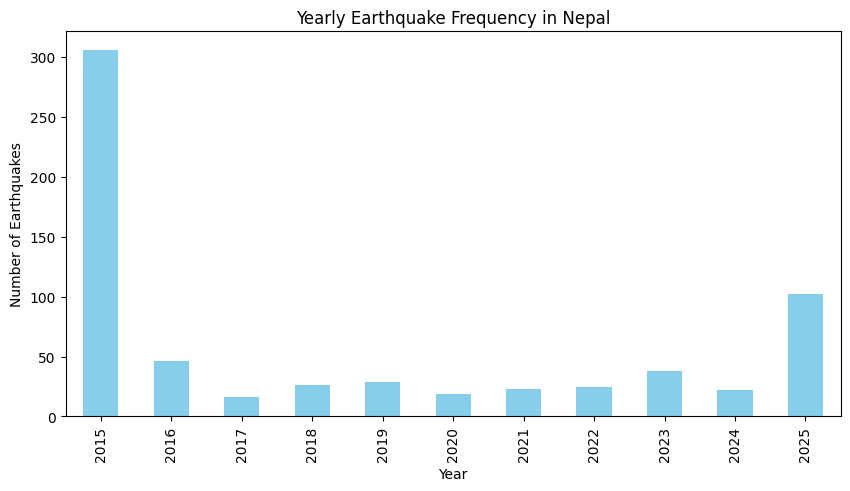

In [ ]:
# Explicitly parse dates when loading
df = pd.read_csv("nepal_earthquakes_2015_2025.csv", parse_dates=['time'])

# Check if time is datetime
print(df['time'].head())
print(df['time'].dtype)

# Extract year
df['year'] = df['time'].dt.year

# Now plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df.groupby('year').size().plot(kind='bar', color='skyblue')
plt.title("Yearly Earthquake Frequency in Nepal")
plt.xlabel("Year")
plt.ylabel("Number of Earthquakes")
plt.show()

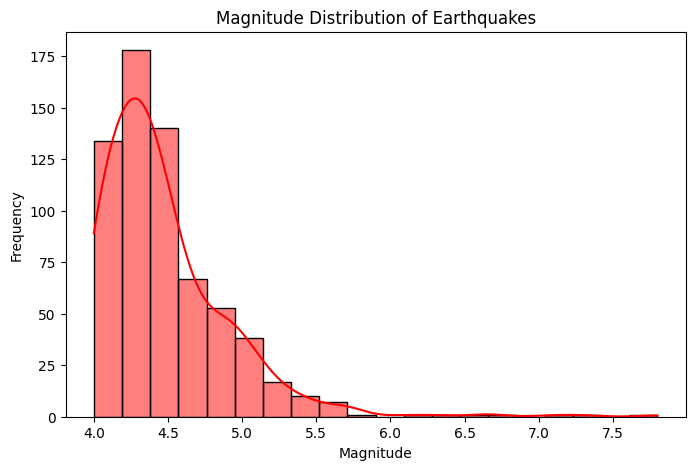

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Magnitude'], bins=20, kde=True, color='red')
plt.title("Magnitude Distribution of Earthquakes")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()


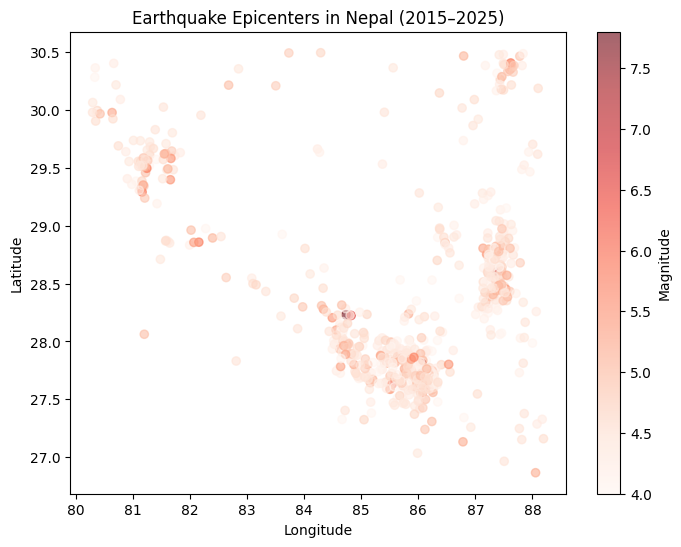

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['Longitude'], df['Latitude'], c=df['Magnitude'], cmap='Reds', alpha=0.6)
plt.colorbar(label="Magnitude")
plt.title("Earthquake Epicenters in Nepal (2015–2025)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
# Machine Learning (Clustering)

X = df[['Latitude','Longitude','Magnitude']]

In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

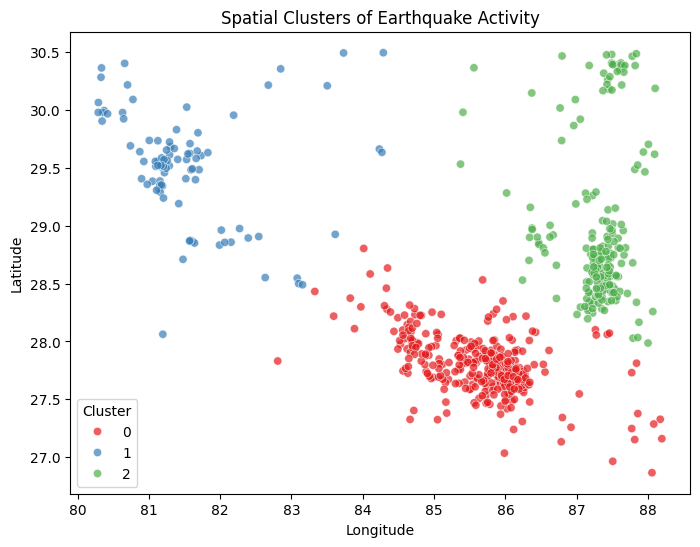

In [ ]:
# Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='cluster', palette='Set1', alpha=0.7)
plt.title("Spatial Clusters of Earthquake Activity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster")
plt.show()


In [ ]:
# Run clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init for clarity
df['cluster'] = kmeans.fit_predict(X_scaled)

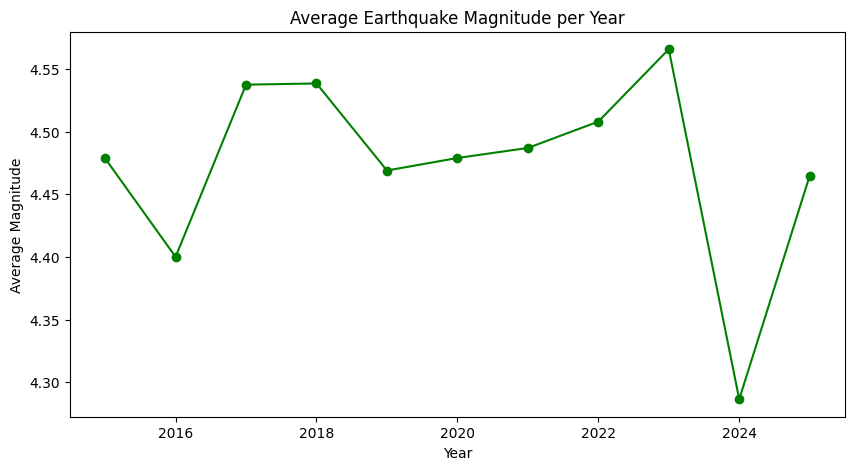

In [ ]:
# Average magnitude per year
avg_mag = df.groupby('year')['Magnitude'].mean()
plt.figure(figsize=(10,5))
avg_mag.plot(marker='o', color='green')
plt.title("Average Earthquake Magnitude per Year")
plt.xlabel("Year")
plt.ylabel("Average Magnitude")
plt.show()

In [ ]:
# Frequency by cluster
cluster_counts = df['cluster'].value_counts()
print("Earthquake counts by cluster:")
print(cluster_counts)

Earthquake counts by cluster:
cluster
0    368
2    192
1     92
Name: count, dtype: int64


In [ ]:
import geopandas as gpd

In [ ]:
import folium

# Center map around Nepal
m = folium.Map(location=[28.3949, 84.1240], zoom_start=6)

# Color palette for clusters
colors = {0:'red', 1:'blue', 2:'green'}

# Add earthquake points
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color=colors[row['cluster']],
        fill=True,
        fill_opacity=0.6,
        popup=f"Magnitude: {row['Magnitude']}, Year: {row['year']}"
    ).add_to(m)

m.save("nepal_earthquake_clusters.html")
